# Model Visualization — 3D Molecular System with PBC

Load a trained flow from a fab-torch `run.py` / `setup_run.py` experiment and
visualize it for a **triatomic solute in explicit TIP3P water** (`SoluteInWater`).

**Atom layout**
```
[sol_0, sol_1, sol_2,  O_0, H1_0, H2_0,  O_1, H1_1, H2_1,  ...]
  ^^^^ solute (3 atoms)       ^^^^ water molecule 0 (O + 2H) ...
```

**Layout**
1. Configuration (paths, device, sample count)
2. Imports
3. Load config + build target (`SoluteInWater`)
4. Reconstruct flow and load checkpoint
5. Generate flow samples
6. Visualization
   - 6.1 Position density scatter (XY / XZ / YZ projections, water O only)
   - 6.2 3-D water-oxygen density heatmaps (XY / XZ / YZ)
   - 6.3 Solute–water and water–water RDF (3-D)
   - 6.4 O–O pairwise distance distributions
   - 6.5 Bond lengths and H–O–H angles
   - 6.6 Energy distributions
   - 6.7 Snapshot gallery (3-D scatter view)
   - 6.8 Animated trajectory *(optional)*


## 1. Configuration

In [1]:
import os

# ── REQUIRED ────────────────────────────────────────────────────────────────
# Directory that contains `config.yaml` and `model_checkpoints/`.
# This is the Hydra output folder produced by setup_run_LJ.py.
# RUN_DIR = "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/12-30-08_398607" 
# RUN_DIR = "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/droplet/stage1/19-10-56_708158"
RUN_DIR = "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage1/LGT/13-19-21_272406"
# ── OPTIONAL ────────────────────────────────────────────────────────────────
# Path to the MD reference trajectory (.h5 or .pt) for comparison plots.
# Set to None to skip MD comparison.
MD_REF_PATH = '/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/data/molecules/md/so2/pbc/v10/traj_so2Inwater.h5'
# MD_REF_PATH = "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/data/molecules/md/so2/droplet/v1/traj_so2Inwater.h5"
# Number of flow samples to generate
N_SAMPLES = 2000
BATCH_SIZE = 256     # reduce if running out of memory

# Device
DEVICE = "cpu"       # "cuda" if a GPU is available

# fab-torch root (only needed when NOT installed as a package)
FAB_TORCH_PATH = os.path.abspath(os.getcwd())


## 2. Imports

In [2]:
import sys
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc, animation
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401
from matplotlib.colors import LogNorm

rc("font", **{"family": "serif"})
rc("mathtext", **{"default": "regular"})

if FAB_TORCH_PATH and FAB_TORCH_PATH not in sys.path:
    sys.path.insert(0, FAB_TORCH_PATH)

from omegaconf import OmegaConf
from fab.target_distributions.solute_in_water import SoluteInWater
from fab.utils.load import load_model, load_md_data, load_checkpoint, build_target
from fab.utils.evaluate import evaluate_models
# Compute functions (pure NumPy, no plotting)
from fab.utils.mol_analysis import (
    compute_rdf_3d,
    compute_min_distances,
    compute_water_geometry,
)
# Visualization functions (accept precomputed data)
from fab.utils.visuals import (
    plot_mol_position_density,
    plot_water_oxygen_heatmaps,
    plot_rdf_3d,
    plot_mol_oo_distances,
    plot_water_geometry,
    plot_mol_energies,
    plot_mol_snapshots,
)

print("PyTorch", torch.__version__, "| CUDA:", torch.cuda.is_available())


Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



PyTorch 2.5.1 | CUDA: False


## 3. Build target

In [3]:
platform = "CPU" if DEVICE == "cpu" else "CUDA"
target_system = build_target(RUN_DIR, MD_REF_PATH, device=DEVICE, platform=platform)

Loading MD data...


/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/fab-torch/fab/target_distributions/solute_in_water.py:111: UserWarning: Found path to .pdb, .inpcrd and .prmtop files. Will use .pdb file.
  warnings.warn("Found path to .pdb, .inpcrd and .prmtop files. Will use .pdb file.")


0 HarmonicBondForce False n/a
1 NonbondedForce True False
2 PeriodicTorsionForce False n/a
3 CMMotionRemover False n/a
4 HarmonicAngleForce False n/a
[ForceGroup] group=0 type=HarmonicBondForce name=HarmonicBondForce
[ForceGroup] group=1 type=NonbondedForce name=NonbondedForce
[ForceGroup] group=2 type=PeriodicTorsionForce name=PeriodicTorsionForce
[ForceGroup] group=3 type=CMMotionRemover name=CMMotionRemover
[ForceGroup] group=4 type=HarmonicAngleForce name=HarmonicAngleForce
system num forces: 5
SYSTEM 0 HarmonicBondForce HarmonicBondForce 0
SYSTEM 1 NonbondedForce NonbondedForce 1
SYSTEM 2 PeriodicTorsionForce PeriodicTorsionForce 2
SYSTEM 3 CMMotionRemover CMMotionRemover 3
SYSTEM 4 HarmonicAngleForce HarmonicAngleForce 4
/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/data/molecules/md/so2/pbc/v10/traj_so2Inwater.h5
OpenMM platform: CPU
Internal dim: 138
NaN frames in val_data_i:   0/100000
OpenMM platform: CPU


In [4]:
# ── System constants ─────────────────────────────────────────────────────────
L              = float(target_system.box_length_nm)           # box side (nm); [0, L)
N_SOLUTE_ATOMS = int(target_system.system.num_atoms_per_solute)   # = 3  (triatomic)
N_ATOMS_WATER  = int(target_system.system.num_atoms_per_solvent)  # = 3  (O, H1, H2)
N_WATERS       = int(target_system.num_solvent_molecules)
N_ATOMS        = target_system.cartesian_dim // 3             # total atoms

# Indices of water-oxygen atoms in the per-frame (N_ATOMS, 3) array
O_IDX  = [N_SOLUTE_ATOMS + N_ATOMS_WATER * k       for k in range(N_WATERS)]
H1_IDX = [N_SOLUTE_ATOMS + N_ATOMS_WATER * k + 1   for k in range(N_WATERS)]
H2_IDX = [N_SOLUTE_ATOMS + N_ATOMS_WATER * k + 2   for k in range(N_WATERS)]

IS_PBC = (target_system.boundary_condition == "pbc")

print(f"System  : triatomic solute + {N_WATERS} water molecules  ({N_ATOMS} atoms total)")
print(f"BC      : {target_system.boundary_condition}  |  box = {L:.3f} nm")
print(f"Cartesian dim : {target_system.cartesian_dim}")


System  : triatomic solute + 22 water molecules  (69 atoms total)
BC      : pbc  |  box = 0.900 nm
Cartesian dim : 207


## 4. Reconstruct flows and load checkpoints

In [5]:
# Single model
cfg, flow = load_model(target_system, RUN_DIR)

# Locate the highest-numbered iter_* checkpoint
model_path, checkpoint = load_checkpoint(RUN_DIR, device="cpu")
flow.load_state_dict(checkpoint["flow"])
flow = flow.to(DEVICE)
flow.eval()
print("Weights loaded.")


Loading iteration 10000 checkpoint: /Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage1/LGT/13-19-21_272406/model_checkpoints/iter_10000/model.pt
Weights loaded.


## 5. Generate flow samples

In [6]:
_x_cart_list, _lp_list = [], []

with torch.no_grad():
    n_done = 0
    while n_done < N_SAMPLES:
        n_now = min(BATCH_SIZE, N_SAMPLES - n_done)
        z, _  = flow.sample_and_log_prob((n_now,))
        x_c, _= target.coordinate_transform.forward(z)
        lp    = target.log_prob(z)
        _x_cart_list.append(x_c.detach().cpu())
        _lp_list.append(lp.detach().cpu())
        n_done += n_now
        if n_done % 500 == 0 or n_done == N_SAMPLES:
            print(f"  {n_done}/{N_SAMPLES}")

# x_flow_flat : (N, 3*N_ATOMS)  flat Cartesian in nm
# x_flow      : (N, N_ATOMS, 3)
x_flow_flat = torch.cat(_x_cart_list).float()
x_flow      = x_flow_flat.view(N_SAMPLES, N_ATOMS, 3).numpy()
u_flow      = (-torch.cat(_lp_list).float()).numpy()

print(f"\nFlow samples : {x_flow.shape}")
print(f"Energy  mean={u_flow.mean():.2f}  std={u_flow.std():.2f}  "
      f"finite={np.isfinite(u_flow).mean()*100:.1f}%")


  2000/2000

Flow samples : (2000, 69, 3)
Energy  mean=989370.00  std=85087.29  finite=100.0%


In [7]:
N_MD_COMPARE = min(5000, target.val_data_i.shape[0])   # cap to avoid slow OpenMM calls on CPU
x_md, u_md = load_md_data(MD_REF_PATH, target, n_md_compare=N_MD_COMPARE, device=DEVICE)

MD reference : (5000, 69, 3) (LGT canonical frame, first 5000 frames)
Energy  mean=-367.13  std=5.64


if target.val_data_x is not None:
    x_md_flat = target.val_data_x.float().cpu()
    x_md      = x_md_flat.view(-1, N_ATOMS, 3).numpy()
    with torch.no_grad():
        lp_md = target.log_prob(
            target.val_data_i.float().to(DEVICE)
        ).cpu()
    u_md = (-lp_md.float()).numpy()
    print(f"MD reference : {x_md.shape}")
    print(f"Energy  mean={u_md.mean():.2f}  std={u_md.std():.2f}")

    # ── Align MD frames to the LGT reference frame ──────────────────────────
    # The LGT forward() always places atom 0 at (L/2, L/2, L/2).
    # Shift each MD frame by the same amount so the comparison is fair.
    _shift  = L / 2 - x_md[:, 0:1, :]      # (N, 1, 3)
    x_md    = (x_md + _shift) % L          # wrap back into [0, L)
    print("MD frames centred: atom-0 → (L/2, L/2, L/2).")
else:
    x_md, u_md = None, None
    print("No MD reference data loaded.")

# Evaluate

## Stage 1

Loading MD data...
0 HarmonicBondForce False n/a
1 NonbondedForce True False
2 PeriodicTorsionForce False n/a
3 CMMotionRemover False n/a
4 HarmonicAngleForce False n/a
[ForceGroup] group=0 type=HarmonicBondForce name=HarmonicBondForce
[ForceGroup] group=1 type=NonbondedForce name=NonbondedForce
[ForceGroup] group=2 type=PeriodicTorsionForce name=PeriodicTorsionForce
[ForceGroup] group=3 type=CMMotionRemover name=CMMotionRemover
[ForceGroup] group=4 type=HarmonicAngleForce name=HarmonicAngleForce
system num forces: 5
SYSTEM 0 HarmonicBondForce HarmonicBondForce 0
SYSTEM 1 NonbondedForce NonbondedForce 1
SYSTEM 2 PeriodicTorsionForce PeriodicTorsionForce 2
SYSTEM 3 CMMotionRemover CMMotionRemover 3
SYSTEM 4 HarmonicAngleForce HarmonicAngleForce 4
/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/data/molecules/md/so2/pbc/v10/traj_so2Inwater.h5
OpenMM platform: CPU
Internal dim: 138
NaN frames in val_data_i:   0/100000
OpenMM platform: CPU
Loading iteration 10000 checkpoint: /Users/

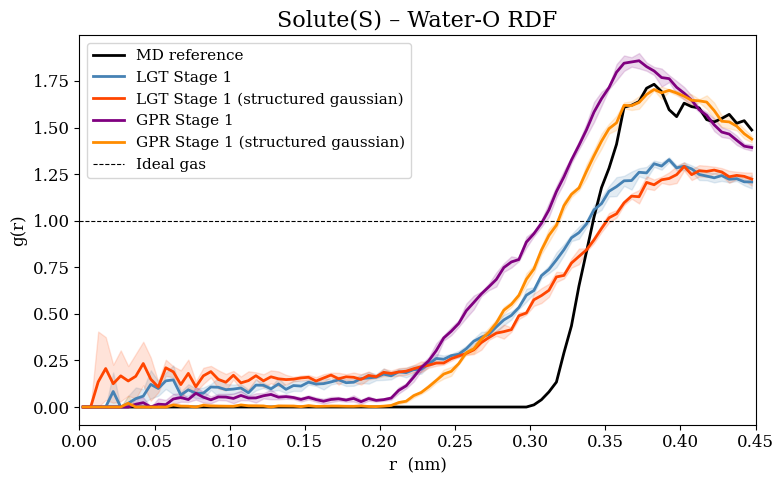

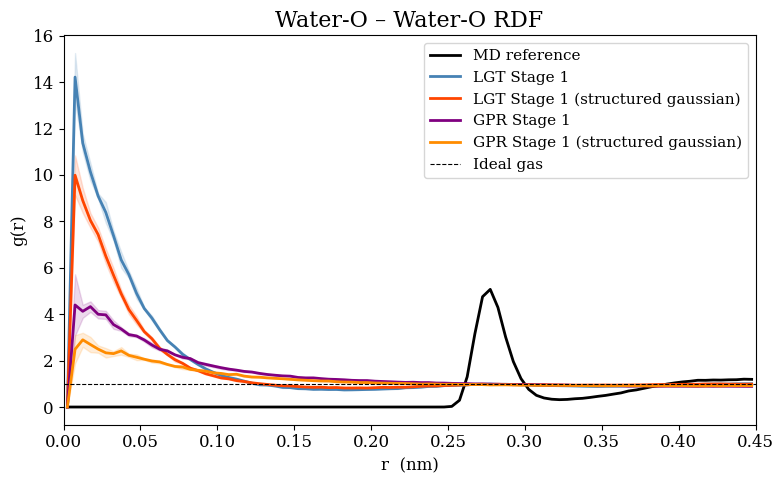

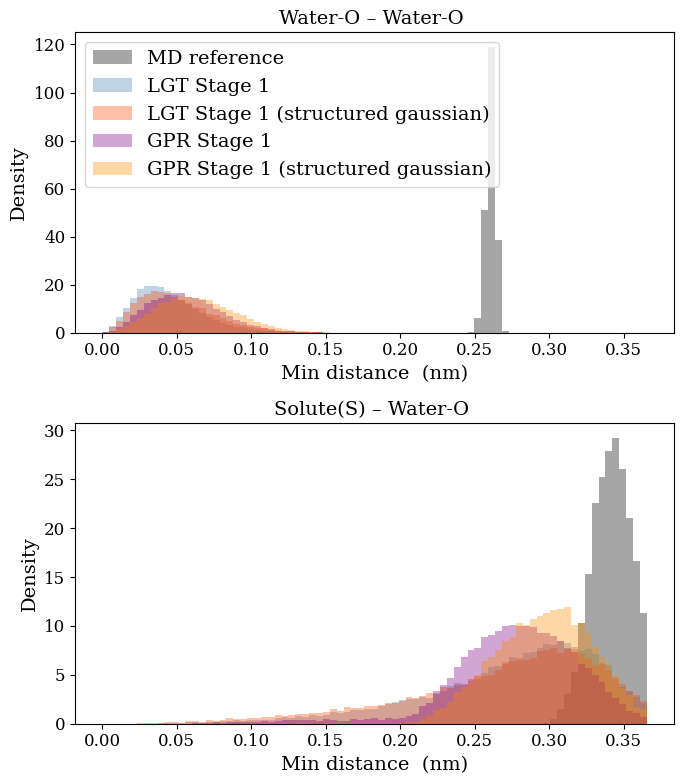

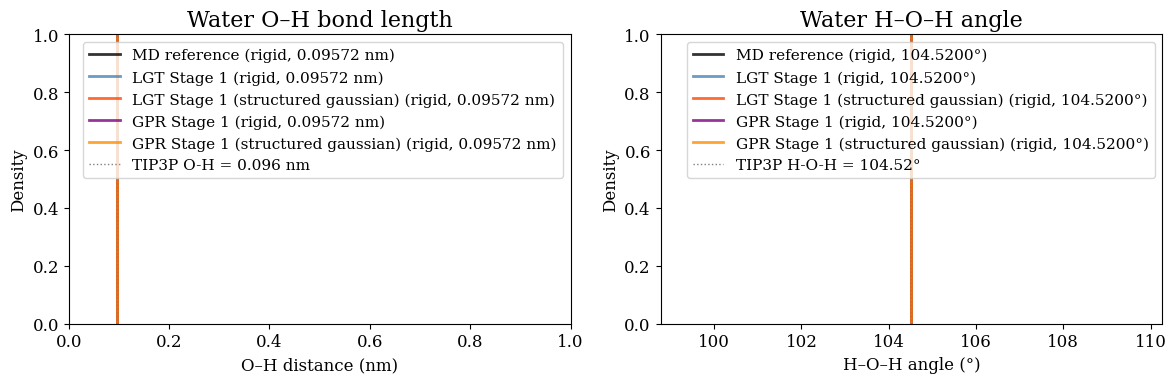

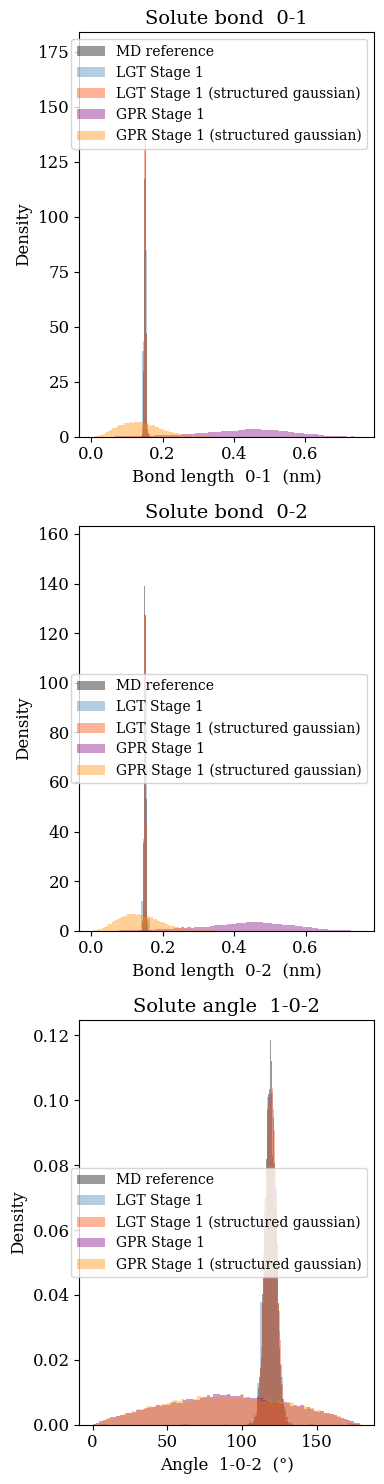

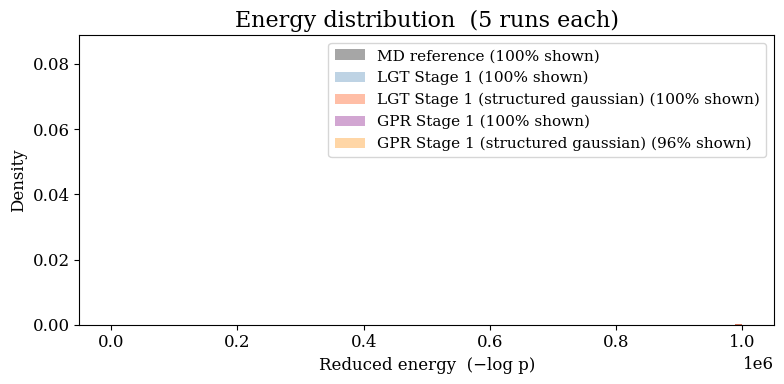


Comparison summary  (5 runs × 5000 samples per model)
Metric                       |               MD reference |                LGT Stage 1 | LGT Stage 1 (structured ga |                GPR Stage 1 | GPR Stage 1 (structured ga
--------------------------------------------------------------------------------------------------------------------------------------
ESS/N (%)                    |                          — |               0.02 ± 0.00% |               0.02 ± 0.00% |               0.02 ± 0.00% |               0.02 ± 0.00%
Energy mean ± std            |               -366.6 ± 5.9 |         991577.8 ± 78523.9 |        980358.7 ± 118671.5 |         987373.9 ± 90809.0 |        958328.7 ± 167906.5
RDF s-w peak                 |                      1.732 |              1.328 ± 0.013 |              1.291 ± 0.022 |              1.859 ± 0.041 |              1.704 ± 0.005
RDF w-w peak                 |                      5.071 |             14.217 ± 1.037 |              9.989 ± 0.85

In [5]:
model_specs = [
    {
    "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage1/LGT/13-19-21_272406",
    "label": "LGT Stage 1",
    },
    {
    "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage1/LGT/structured_gauss/22-35-31_052320",
    "label": "LGT Stage 1 (structured gaussian)",
    },

    
    # {
    # "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/LGT/12-30-08_398607",
    # "label": "LGT Stage 2",
    # },
    # {
    # "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/LGT/structured_gauss/11-01-38_439278",
    # "label": "LGT Stage 2 (structured gaussian)",
    # },
    {
    "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage1/GPR/22-28-27_109465",
    "label": "GPR Stage 1",
    },
    {
    "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage1/GPR/structured_gauss/22-35-19_938741",
    "label": "GPR Stage 1 (structured gaussian)",
    },
    # {
    # "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/GPR/10-52-27_144440",
    # "label": "GPR Stage 2",
    # },
    # {
    # "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/GPR/structured_gauss/11-01-18_217693",
    # "label": "GPR Stage 2 (structured gaussian)",
    # },
    
]

# model_specs = [
#     {
#     "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/droplet/stage1/19-10-56_708158",
#     "label": "GPS Stage 1",
#     },
# ]

results = evaluate_models(MD_REF_PATH,
    model_specs,
    N_SOLUTE_ATOMS,
    N_WATERS,
    O_IDX,
    H1_IDX,
    H2_IDX,
    L,
    IS_PBC,
    solute_bonds=[(0,1),(0,2)], 
    solute_angles=[(1,0,2)]
)


## Stage 2

In [ ]:
model_specs = [
    
    {
    "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/LGT/12-30-08_398607",
    "label": "LGT Stage 2",
    },
    {
    "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/LGT/structured_gauss/11-01-38_439278",
    "label": "LGT Stage 2 (structured gaussian)",
    },
    {
    "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/GPR/10-52-27_144440",
    "label": "GPR Stage 2",
    },
    {
    "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/GPR/structured_gauss/11-01-18_217693",
    "label": "GPR Stage 2 (structured gaussian)",
    },
    
]

results = evaluate_models(MD_REF_PATH,
    model_specs,
    N_SOLUTE_ATOMS,
    N_WATERS,
    O_IDX,
    H1_IDX,
    H2_IDX,
    L,
    IS_PBC,
    solute_bonds=[(0,1),(0,2)], 
    solute_angles=[(1,0,2)]
)


## Stage 3

In [ ]:
# model_specs = [
    
#     {
#     "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/LGT/12-30-08_398607",
#     "label": "LGT Stage 2",
#     },
#     {
#     "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/LGT/structured_gauss/11-01-38_439278",
#     "label": "LGT Stage 2 (structured gaussian)",
#     },
#     {
#     "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/GPR/10-52-27_144440",
#     "label": "GPR Stage 2",
#     },
#     {
#     "run_dir": "/Users/fleurdolmans/Documents/UvA/Master_AI/Thesis/HDD/results/so2/stage2/GPR/structured_gauss/11-01-18_217693",
#     "label": "GPR Stage 2 (structured gaussian)",
#     },
    
# ]

results = evaluate_models(MD_REF_PATH,
    model_specs,
    N_SOLUTE_ATOMS,
    N_WATERS,
    O_IDX,
    H1_IDX,
    H2_IDX,
    L,
    IS_PBC,
    solute_bonds=[(0,1),(0,2)], 
    solute_angles=[(1,0,2)]
)

### 6.1  Position density scatter (XY / XZ / YZ, water-O only)

In [ ]:
_datasets = [(x_flow, "Flow samples")]
if x_md is not None:
    _datasets.insert(0, (x_md, "MD reference"))

plot_mol_position_density(_datasets, L, O_IDX, N_SOLUTE_ATOMS, IS_PBC)


### 6.2  3-D water-oxygen density heatmaps (XY / XZ / YZ)

In [ ]:
_datasets = [(x_flow, "Flow")]
if x_md is not None:
    _datasets.insert(0, (x_md, "MD"))

plot_water_oxygen_heatmaps(_datasets, L, O_IDX, N_SOLUTE_ATOMS, IS_PBC)


### 6.3  Solute–water and water–water RDF (3-D)

In [ ]:
_L_rdf = L if IS_PBC else None

r_sw_flow, g_sw_flow = compute_rdf_3d(x_flow, [0], O_IDX, _L_rdf, dr=0.005)
r_ww_flow, g_ww_flow = compute_rdf_3d(x_flow, O_IDX, O_IDX, _L_rdf, dr=0.005)

sw_curves = [(r_sw_flow, g_sw_flow, "Flow")]
ww_curves = [(r_ww_flow, g_ww_flow, "Flow")]

if x_md is not None:
    r_sw_md, g_sw_md = compute_rdf_3d(x_md, [0], O_IDX, _L_rdf, dr=0.005)
    r_ww_md, g_ww_md = compute_rdf_3d(x_md, O_IDX, O_IDX, _L_rdf, dr=0.005)
    sw_curves.insert(0, (r_sw_md, g_sw_md, "MD reference"))
    ww_curves.insert(0, (r_ww_md, g_ww_md, "MD reference"))

plot_rdf_3d(sw_curves, ww_curves, L, IS_PBC)


### 6.4  O–O pairwise distance distributions

In [ ]:
d_ww_flow, d_sw_flow = compute_min_distances(x_flow, O_IDX, L, IS_PBC)

ww_dists = [(d_ww_flow, "Flow")]
sw_dists = [(d_sw_flow, "Flow")]

if x_md is not None:
    d_ww_md, d_sw_md = compute_min_distances(x_md, O_IDX, L, IS_PBC)
    ww_dists.insert(0, (d_ww_md, "MD"))
    sw_dists.insert(0, (d_sw_md, "MD"))

plot_mol_oo_distances(ww_dists, sw_dists)


### 6.5  Bond lengths and H–O–H angles

In [ ]:
oh_flow, hoh_flow = compute_water_geometry(x_flow, N_WATERS, O_IDX, H1_IDX, H2_IDX, L, IS_PBC)

oh_datasets  = [(oh_flow,  "Flow", "steelblue")]
hoh_datasets = [(hoh_flow, "Flow", "steelblue")]

if x_md is not None:
    oh_md, hoh_md = compute_water_geometry(x_md, N_WATERS, O_IDX, H1_IDX, H2_IDX, L, IS_PBC)
    oh_datasets.insert(0,  (oh_md,  "MD", "black"))
    hoh_datasets.insert(0, (hoh_md, "MD", "black"))

plot_water_geometry(oh_datasets, hoh_datasets)


### 6.6  Energy distributions

In [ ]:
plot_mol_energies(u_flow, u_md)


### 6.7  Snapshot gallery (3-D scatter view)

In [ ]:
_sources = [(x_flow, "Flow")]
if x_md is not None:
    _sources.insert(0, (x_md, "MD"))

plot_mol_snapshots(_sources, L, N_SOLUTE_ATOMS, O_IDX, H1_IDX, H2_IDX, IS_PBC, n_snap=4)


### 6.8  Animated trajectory *(optional)*

KeyboardInterrupt: 

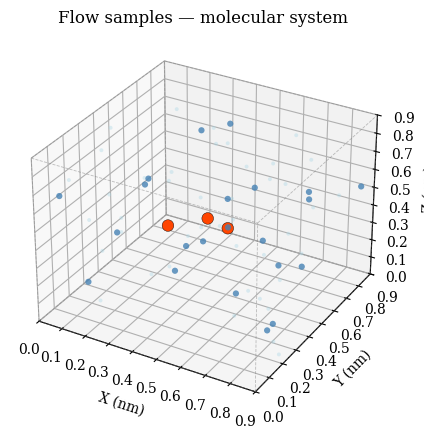

In [32]:
mpl.rcParams["animation.html"] = "jshtml"

N_ANIM = min(200, N_SAMPLES)
x_anim = x_flow[:N_ANIM]

fig  = plt.figure(figsize=(5, 5))
ax3d = fig.add_subplot(111, projection="3d")
if IS_PBC:
    ax3d.set_xlim(0, L); ax3d.set_ylim(0, L); ax3d.set_zlim(0, L)
ax3d.set_xlabel("X (nm)"); ax3d.set_ylabel("Y (nm)"); ax3d.set_zlabel("Z (nm)")
ax3d.set_title("Flow samples — molecular system")

if IS_PBC:
    for _i in range(2):
        for _j in range(2):
            ax3d.plot([0,L],[_i*L,_i*L],[_j*L,_j*L], c="gray",ls="--",lw=0.6,alpha=0.5)
            ax3d.plot([_i*L,_i*L],[0,L],[_j*L,_j*L], c="gray",ls="--",lw=0.6,alpha=0.5)
            ax3d.plot([_i*L,_i*L],[_j*L,_j*L],[0,L], c="gray",ls="--",lw=0.6,alpha=0.5)

sc_h   = ax3d.scatter([], [], [], s=8,  c="lightblue", alpha=0.4, edgecolors="none")
sc_o   = ax3d.scatter([], [], [], s=20, c="steelblue", alpha=0.8, edgecolors="none")
sc_sol = ax3d.scatter([], [], [], s=70, c="orangered", alpha=1.0,
                      edgecolors="black", linewidths=0.3)

def _upd(frame):
    pos = x_anim[frame]
    sc_h._offsets3d   = tuple(pos[H1_IDX + H2_IDX].T)
    sc_o._offsets3d   = tuple(pos[O_IDX].T)
    sc_sol._offsets3d = tuple(pos[:N_SOLUTE_ATOMS].T)
    return sc_h, sc_o, sc_sol

ani = animation.FuncAnimation(fig, _upd, frames=N_ANIM, interval=100, blit=False)

from IPython.display import display
display(ani)


# Evaluate ESS

In [103]:
# ── ESS sanity check ──────────────────────────────────────────────────────
import torch
import numpy as np
from scipy.special import logsumexp

n_check = 2000

with torch.no_grad():
    z_ess, log_q_t = flow.sample_and_log_prob((n_check,))
    log_p_t = target.log_prob(z_ess)

log_q = log_q_t.float().numpy()
log_p = log_p_t.float().numpy()
log_w = log_p - log_q        # importance weights in log space

finite_mask = np.isfinite(log_w)
log_w_f = log_w[finite_mask]
print(f"Finite samples: {finite_mask.sum()} / {n_check}  ({finite_mask.mean()*100:.1f}%)")

print("\n=== Log-density statistics ===")
print(f"log_q(z):  mean={log_q.mean():.2f}, std={log_q.std():.2f}")
lp_fin = log_p[np.isfinite(log_p)]
print(f"log_p(z):  mean={lp_fin.mean():.2f}, std={lp_fin.std():.2f}")
print(f"log_w:     mean={log_w_f.mean():.2f}, std={log_w_f.std():.2f}")

ess = np.exp(2 * logsumexp(log_w_f) - logsumexp(2 * log_w_f))
print(f"\nESS: {ess:.1f} / {n_check}  ({ess/n_check*100:.1f}%)")
print("(low std of log_w → high ESS → flow is well-calibrated)")

Finite samples: 2000 / 2000  (100.0%)

=== Log-density statistics ===
log_q(z):  mean=-184.79, std=8.52
log_p(z):  mean=-10101.62, std=9.17
log_w:     mean=-9916.82, std=5.67

ESS: 1.0 / 2000  (0.1%)
(low std of log_w → high ESS → flow is well-calibrated)


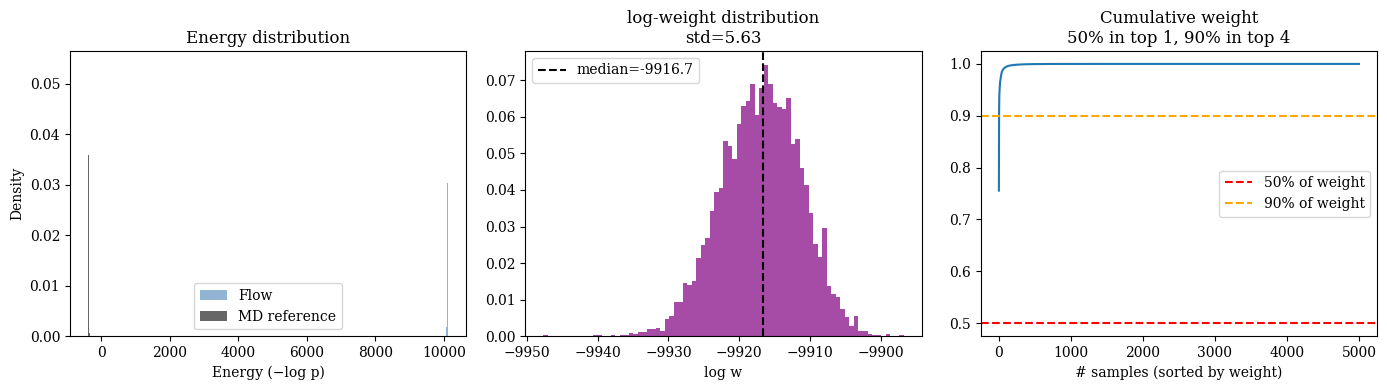

ESS: 1.7 / 5000  (0.0%)
log_w: mean=-9916.94, std=5.63
50% of total weight in 1/5000 samples (0.02%)
90% of total weight in 4/5000 samples (0.08%)


In [104]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import logsumexp

n_check = 5000

with torch.no_grad():
    z_w, log_q_w_t = flow.sample_and_log_prob((n_check,))
    log_p_w_t = target.log_prob(z_w)

log_q_w = log_q_w_t.float().numpy()
log_p_w = log_p_w_t.float().numpy()
energies_w = -log_p_w           # reduced energy = -log p(z)
log_w = log_p_w - log_q_w       # importance weights in log space

finite_mask = np.isfinite(log_w)
log_w_f = log_w[finite_mask]
n_finite = int(finite_mask.sum())

# Normalize weights for cumulative-weight plot
log_w_norm = log_w_f - logsumexp(log_w_f)
w_norm = np.exp(log_w_norm)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Energy distribution (flow vs MD reference if available)
e_finite = energies_w[np.isfinite(energies_w)]
e_max = float(np.percentile(e_finite, 99))
axes[0].hist(e_finite[e_finite < e_max], bins=80, density=True,
             alpha=0.6, label='Flow', color='steelblue')
if u_md is not None:
    u_md_f = u_md[np.isfinite(u_md)]
    axes[0].hist(u_md_f[u_md_f < e_max], bins=40, density=True,
                 alpha=0.6, label='MD reference', color='black')
axes[0].set_xlabel('Energy (−log p)'); axes[0].set_ylabel('Density')
axes[0].set_title('Energy distribution'); axes[0].legend()

# 2. Distribution of log importance weights
axes[1].hist(log_w_f, bins=80, density=True, color='purple', alpha=0.7)
axes[1].axvline(np.median(log_w_f), color='k', ls='--',
                label=f'median={np.median(log_w_f):.1f}')
axes[1].set_xlabel('log w')
axes[1].set_title(f'log-weight distribution\nstd={log_w_f.std():.2f}')
axes[1].legend()

# 3. Cumulative weight: how many samples carry most of the weight?
w_sorted = np.sort(w_norm)[::-1]
cumw = np.cumsum(w_sorted)
axes[2].plot(np.arange(1, n_finite + 1), cumw)
axes[2].axhline(0.5, color='r', ls='--', label='50% of weight')
axes[2].axhline(0.9, color='orange', ls='--', label='90% of weight')
n50 = int(np.searchsorted(cumw, 0.5)) + 1
n90 = int(np.searchsorted(cumw, 0.9)) + 1
axes[2].set_xlabel('# samples (sorted by weight)')
axes[2].set_title(f'Cumulative weight\n50% in top {n50}, 90% in top {n90}')
axes[2].legend()

plt.tight_layout(); plt.show()

ess = np.exp(2 * logsumexp(log_w_f) - logsumexp(2 * log_w_f))
print(f"ESS: {ess:.1f} / {n_check}  ({ess/n_check*100:.1f}%)")
print(f"log_w: mean={log_w_f.mean():.2f}, std={log_w_f.std():.2f}")
print(f"50% of total weight in {n50}/{n_finite} samples ({n50/n_finite*100:.2f}%)")
print(f"90% of total weight in {n90}/{n_finite} samples ({n90/n_finite*100:.2f}%)")

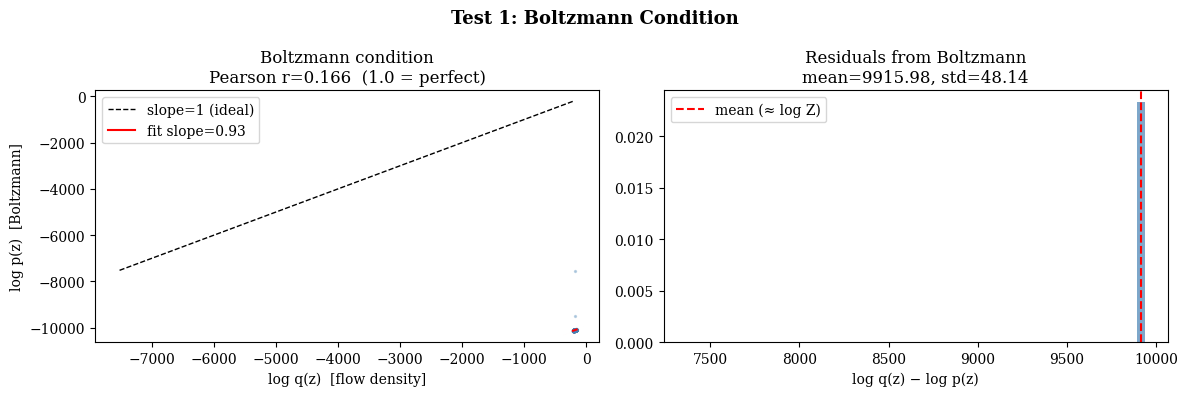

Pearson r(log_q, log_p): 0.1663   (ideal=1.0, random≈0.0)
Fit slope:               0.9326  (ideal=1.0)
Residual std:            48.1373  (= sqrt(Var[log_w]), ideal→0)
Residual mean:           9915.98  (≈ log Z, the partition function)


In [105]:
# ── Test 1: Boltzmann condition scatter ──────────────────────────────────────
# A perfect flow satisfies log q(z) ∝ log p(z), i.e. slope=1, Pearson r=1.
# The residual log q(z) − log p(z) is the log-normalisation constant log Z.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress

N_TEST = 3000

with torch.no_grad():
    z_bc, log_q_bc_t = flow.sample_and_log_prob((N_TEST,))
    log_p_bc_t = target.log_prob(z_bc)

log_q_bc = log_q_bc_t.float().numpy()
log_p_bc = log_p_bc_t.float().numpy()

finite_mask = np.isfinite(log_q_bc) & np.isfinite(log_p_bc)
log_q_f = log_q_bc[finite_mask]
log_p_f = log_p_bc[finite_mask]
log_w_f = log_p_f - log_q_f

r, _ = pearsonr(log_q_f, log_p_f)
slope, intercept, *_ = linregress(log_q_f, log_p_f)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: log_q vs log_p
axes[0].scatter(log_q_f, log_p_f, s=2, alpha=0.3, c='steelblue')
lim_lo = max(log_q_f.min(), log_p_f.min()) - 5
lim_hi = min(log_q_f.max(), log_p_f.max()) + 5
axes[0].plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1, label='slope=1 (ideal)')
fit_x = np.linspace(log_q_f.min(), log_q_f.max(), 100)
axes[0].plot(fit_x, slope * fit_x + intercept, 'r-', lw=1.5,
             label=f'fit slope={slope:.2f}')
axes[0].set_xlabel('log q(z)  [flow density]')
axes[0].set_ylabel('log p(z)  [Boltzmann]')
axes[0].set_title(f'Boltzmann condition\nPearson r={r:.3f}  (1.0 = perfect)')
axes[0].legend()

# Residuals: log_q(z) − log_p(z) ≈ log Z (should be ~constant)
residuals = log_q_f - log_p_f
axes[1].hist(residuals, bins=60, density=True, color='steelblue', alpha=0.7)
axes[1].set_xlabel('log q(z) − log p(z)')
axes[1].set_title(f'Residuals from Boltzmann\nmean={residuals.mean():.2f}, std={residuals.std():.2f}')
axes[1].axvline(residuals.mean(), color='r', ls='--', label='mean (≈ log Z)')
axes[1].legend()

plt.suptitle('Test 1: Boltzmann Condition', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Pearson r(log_q, log_p): {r:.4f}   (ideal=1.0, random≈0.0)")
print(f"Fit slope:               {slope:.4f}  (ideal=1.0)")
print(f"Residual std:            {residuals.std():.4f}  (= sqrt(Var[log_w]), ideal→0)")
print(f"Residual mean:           {residuals.mean():.2f}  (≈ log Z, the partition function)")

In [106]:
# ── Test 2: Latent space quality (MD samples → base space) ──────────────────
# Encodes MD reference samples (internal coords) through the inverse flow
# to check whether they map to Gaussian(0,1) in the base (latent) space.
# Requires MD data: set MD_REF_PATH in cell 2 and re-run cells 3–5.
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

if target.val_data_i is None:
    print("Test 2 skipped: no MD reference data loaded.")
    print("Set MD_REF_PATH in cell 2 to the trajectory file and re-run.")
else:
    z_md = target.val_data_i.float().to(DEVICE)

    # Encode internal coords → base space by reversing each flow layer
    with torch.no_grad():
        h = z_md.clone()
        for layer in reversed(flow.flows):
            h, _ = layer.inverse(h)
        z_latent = h.cpu().float().numpy()    # (n_md, internal_dim)

    print(f"z_latent shape : {z_latent.shape}")
    print(f"z mean  : {z_latent.mean():.4f}  (ideal 0)")
    print(f"z std   : {z_latent.std():.4f}   (ideal 1)")

    n_coords = z_latent.shape[1]
    ks_stats = np.array([
        stats.kstest(z_latent[:, i], 'norm').statistic
        for i in range(n_coords)
    ])
    coord_means = z_latent.mean(axis=0)
    coord_stds  = z_latent.std(axis=0)

    top5 = np.argsort(ks_stats)[-5:]
    bar_colors = ['crimson' if i in top5 else 'purple' for i in range(n_coords)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].bar(range(n_coords), np.abs(coord_means),
                color='steelblue', alpha=0.7, label='|mean| (ideal 0)')
    axes[0].axhline(0.05, color='r', ls='--', label='0.05 threshold')
    axes[0].set_xlabel('Latent coordinate index'); axes[0].set_ylabel('|mean|')
    axes[0].set_title('Per-coordinate |mean| of z'); axes[0].legend()

    axes[1].bar(range(n_coords), coord_stds,
                color='orangered', alpha=0.7, label='std (ideal 1)')
    axes[1].axhline(1.0, color='k', ls='--', label='ideal std=1')
    axes[1].set_xlabel('Latent coordinate index'); axes[1].set_ylabel('std')
    axes[1].set_title('Per-coordinate std of z'); axes[1].legend()

    axes[2].bar(range(n_coords), ks_stats, color=bar_colors, alpha=0.8)
    axes[2].axhline(0.05, color='r', ls='--', label='KS=0.05 threshold')
    axes[2].set_xlabel('Latent coordinate index'); axes[2].set_ylabel('KS statistic')
    axes[2].set_title(
        f'Per-coord KS-test (crimson = top 5 worst)\n'
        f'max KS={ks_stats.max():.3f} at coord {int(ks_stats.argmax())}'
    )
    axes[2].legend()

    plt.suptitle('Test 2: Latent Space Quality (MD → z)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f"\nWorst 5 latent coordinates (KS statistic):")
    for i in sorted(top5):
        print(f"  coord {i:3d}: KS={ks_stats[i]:.4f}, mean={coord_means[i]:.4f}, "
              f"std={coord_stds[i]:.4f}")

AttributeError: 'WrappedNormFlowModel' object has no attribute 'flows'

In [ ]:
# ── Test 3: Per-layer log|det J| decomposition (normflows) ──────────────────
# Traces how the Jacobian log-determinant builds up across flow layers in the
# generative direction (base → internal coords).
# A layer with high Var(log|det|) dominates importance-weight variance.
import numpy as np
import matplotlib.pyplot as plt

N_TEST = 2000

# Sample from base distribution and trace through all flow layers
with torch.no_grad():
    z0, _ = flow.q0(N_TEST)
    z0 = z0.float()

per_layer_logdet = []
with torch.no_grad():
    h = z0.clone()
    for layer in flow.flows:
        h_new, ld = layer(h)
        per_layer_logdet.append(ld.float().numpy())
        h = h_new

per_layer_logdet  = np.array(per_layer_logdet)         # (n_layers, N_TEST)
cumulative_logdet = per_layer_logdet.cumsum(axis=0)
n_layers = len(per_layer_logdet)
x_ax = np.arange(n_layers)

layer_means = per_layer_logdet.mean(axis=1)
layer_stds  = per_layer_logdet.std(axis=1)
high_var = layer_stds > layer_stds.mean() + layer_stds.std()
bar_colors = ['crimson' if hv else 'steelblue' for hv in high_var]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Per-layer mean ± std
axes[0].bar(x_ax, layer_means, yerr=layer_stds, capsize=2,
            color=bar_colors, alpha=0.8)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_xlabel('Flow layer index'); axes[0].set_ylabel('log|det| (mean ± std)')
axes[0].set_title('Per-layer log|det J|\n(crimson = high-variance layers)')

# 2. Cumulative log|det| with spread
axes[1].fill_between(
    x_ax,
    cumulative_logdet.mean(1) - cumulative_logdet.std(1),
    cumulative_logdet.mean(1) + cumulative_logdet.std(1),
    alpha=0.3, color='orangered'
)
axes[1].plot(x_ax, cumulative_logdet.mean(1), 'r-o', markersize=3)
axes[1].set_xlabel('After layer k'); axes[1].set_ylabel('Cumulative log|det|')
axes[1].set_title('Cumulative log|det| mean ± std\n(wider = more weight variance)')

# 3. Variance per layer
top3 = np.argsort(layer_stds**2)[-3:]
vbar_colors = ['crimson' if i in top3 else 'purple' for i in range(n_layers)]
axes[2].bar(x_ax, layer_stds**2, color=vbar_colors, alpha=0.8)
axes[2].set_xlabel('Flow layer index'); axes[2].set_ylabel('Var(log|det|)')
axes[2].set_title(f'Variance per layer  (top 3: {sorted(top3)})')

plt.suptitle('Test 3: Per-Layer log|det J| Decomposition', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"{'Layer':>6} | {'mean':>8} | {'std':>8} | {'var':>8}")
print("-" * 42)
for i, (m, s) in enumerate(zip(layer_means, layer_stds)):
    flag = "  <-- HIGH VAR" if high_var[i] else ""
    print(f"{i:6d} | {m:8.3f} | {s:8.3f} | {s**2:8.3f}{flag}")
print(f"\nTotal cumulative log|det| std : {cumulative_logdet[-1].std():.3f}")
print(f"Sum of per-layer variances   : {(layer_stds**2).sum():.3f}")

In [ ]:
# ── Test 4: High-weight vs low-weight sample inspection ─────────────────────
# XY projection of 3D configurations sorted by importance weight.
# High-weight samples resemble the target; low-weight ones do not.
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

N_TEST = 5000

with torch.no_grad():
    z_t4, log_q_t4_t = flow.sample_and_log_prob((N_TEST,))
    log_p_t4_t = target.log_prob(z_t4)
    x_c_t4, _ = target.coordinate_transform.forward(z_t4)

log_q_t4 = log_q_t4_t.float().numpy()
log_p_t4 = log_p_t4_t.float().numpy()
energies_t4 = -log_p_t4
log_w_t4 = log_p_t4 - log_q_t4

finite_mask = np.isfinite(log_w_t4)
n_finite = int(finite_mask.sum())
log_w_f = log_w_t4[finite_mask]
x_cart_t4 = x_c_t4.float().cpu().numpy()[finite_mask].reshape(n_finite, N_ATOMS, 3)
e_f4 = energies_t4[finite_mask]

# Sort by weight (descending)
log_w_norm = log_w_f - logsumexp(log_w_f)
w_norm = np.exp(log_w_norm)
order = np.argsort(w_norm)[::-1]
x_sorted = x_cart_t4[order]
w_sorted = w_norm[order]
e_sorted = e_f4[order]

cumw = np.cumsum(w_sorted)
n50 = int(np.searchsorted(cumw, 0.5)) + 1
n90 = int(np.searchsorted(cumw, 0.9)) + 1
print(f"Top {n50}/{n_finite} samples ({n50/n_finite*100:.2f}%) carry 50% of total weight")
print(f"Top {n90}/{n_finite} samples ({n90/n_finite*100:.2f}%) carry 90% of total weight")
print(f"Energy of top-5 by weight: {[f'{v:.0f}' for v in e_sorted[:5]]}")


def _plot_config_xy(ax, pos, title, L=None):
    """XY projection of one configuration (N_ATOMS, 3)."""
    o_xy   = pos[O_IDX,  :2]
    sol_xy = pos[:N_SOLUTE_ATOMS, :2]
    ax.scatter(o_xy[:, 0], o_xy[:, 1], s=30, c='steelblue', alpha=0.7)
    ax.scatter(sol_xy[:, 0], sol_xy[:, 1], s=120, c='orangered',
               marker='*', zorder=5)
    if L is not None:
        ax.add_patch(plt.Rectangle((0, 0), L, L, fill=False, ec='gray', ls='--'))
        ax.set_xlim(-0.05*L, 1.05*L); ax.set_ylim(-0.05*L, 1.05*L)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=9)
    ax.set_xlabel('X (nm)'); ax.set_ylabel('Y (nm)')


fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Top row: 3 highest-weight samples
for col in range(3):
    _plot_config_xy(
        axes[0, col], x_sorted[col],
        f'High-weight #{col+1}\nE={e_sorted[col]:.0f},  w={w_sorted[col]*n_finite:.3f}×(1/N)',
        L=L if IS_PBC else None,
    )

# Bottom row: 3 random low-weight samples (bottom 25%)
rng = np.random.default_rng(42)
bottom_positions = rng.choice(np.arange(n_finite * 3 // 4, n_finite), 3, replace=False)
for col, pos in enumerate(bottom_positions):
    _plot_config_xy(
        axes[1, col], x_sorted[pos],
        f'Low-weight sample\nE={e_sorted[pos]:.0f},  w≈0',
        L=L if IS_PBC else None,
    )

axes[0, 0].set_ylabel('High-weight samples', fontsize=11)
axes[1, 0].set_ylabel('Low-weight samples', fontsize=11)
plt.suptitle('Test 4: High-weight vs Low-weight configurations (XY projection)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Energy histogram split by weight class
top10_mask = np.zeros(n_finite, dtype=bool)
top10_mask[order[:n_finite // 10]] = True
e_fin = e_f4[np.isfinite(e_f4)]
e_max_plot = float(np.percentile(e_fin, 99))
bins = np.linspace(float(e_fin.min()), e_max_plot, 60)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(e_f4[top10_mask & np.isfinite(e_f4)], bins=bins, density=True,
        alpha=0.6, label='Top 10% by weight', color='green')
ax.hist(e_f4[~top10_mask & np.isfinite(e_f4)], bins=bins, density=True,
        alpha=0.6, label='Bottom 90% by weight', color='gray')
if u_md is not None:
    u_md_fin = u_md[np.isfinite(u_md)]
    ax.hist(u_md_fin[u_md_fin < e_max_plot], bins=bins, density=True,
            alpha=0.6, label='MD reference', color='steelblue')
ax.set_xlabel('Energy (−log p)'); ax.set_title('Energy distribution by weight class')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ── Test 5: ESS scaling with sample size ────────────────────────────────────
# For a well-generalising flow, ESS/N stays roughly constant as N grows.
# A sharply decreasing ESS/N indicates "lottery ticket" behaviour where a
# tiny fraction of samples dominates the weights.
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

sample_sizes = [100, 250, 500, 1000, 2000, 5000]
ess_vals = []

for n in sample_sizes:
    with torch.no_grad():
        z_s, lq_s = flow.sample_and_log_prob((n,))
        lp_s = target.log_prob(z_s)
    lw = (lp_s - lq_s).float().numpy()
    lw_f = lw[np.isfinite(lw)]
    if len(lw_f) < 2:
        ess_vals.append(0.0)
    else:
        ess_vals.append(float(np.exp(2 * logsumexp(lw_f) - logsumexp(2 * lw_f))))

ess_frac = [e / n for e, n in zip(ess_vals, sample_sizes)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sample_sizes, ess_vals, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('N (sample size)'); axes[0].set_ylabel('ESS')
axes[0].set_title('Absolute ESS vs sample size')

axes[1].plot(sample_sizes, ess_frac, 'o-', color='steelblue', lw=2)
axes[1].axhline(ess_frac[0], color='gray', ls='--', alpha=0.5,
                label=f'first ESS/N = {ess_frac[0]:.3f}')
axes[1].set_xlabel('N (sample size)'); axes[1].set_ylabel('ESS / N')
axes[1].set_title('Relative ESS/N vs sample size\n(flat = good;  decreasing = weight collapse)')
axes[1].legend()

plt.suptitle('Test 5: ESS Scaling Diagnosis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"{'N':>6} | {'ESS':>8} | {'ESS/N':>8}")
print("-" * 30)
for n, e, f in zip(sample_sizes, ess_vals, ess_frac):
    print(f"{n:6d} | {e:8.1f} | {f:8.4f}")